# SIR Simulator: Conjugate Method (Case 1) Notebook

This notebook demonstrates how to run the conjugate posterior estimation (Case 1) for the SIR simulator.

It covers:
1. Setting up the SIR simulator.
2. Generating training data and training the `q_phi` neural networks.
3. Generating observed data with outliers.
4. Calibrating $\beta$ using the GPC method.
5. Computing the conjugate posterior mean and covariance.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.distributions import MultivariateNormal

from nsm_bayes.models.conjugate import ConjugateModel
from nsm_bayes.gpc import calibrate_beta_gpc
from nsm_bayes.method import (
    compute_posterior_case1,
    robust_mean_cov,
    w_imq_squared,
)

from nsm_bayes.simulators.benchmark_simulators.simulators import (
    simulate_sir,
    sir_summary,
)

## 1. Configuration

Set some values for the parameters. The SIR simulator has four different parameters. 

In [8]:
cfg = {
    "prior_mean": [0.5, 0.2, 0.5, 20],
    "prior_std": [0.5, 0.5, 1.0, 0.7],
    "theta_true": [0.6, 0.15, 0.6, 20.0],
    "N_sir": 1000,
    "T_sir": 150,
    "num_samples": 5000,
    "d_x": 3,
    "hidden_dim": 128,
    "beta_base_case1": 0.01,
    "beta_min_case1": 1e-4,
    "alpha": 0.05,
    "T": 20,
    "B": 100,
    "epsilon": 0.05,
    "n_obs": 100
}

dtype = torch.float32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

prior_mean = torch.tensor([
    torch.log(torch.tensor(cfg["prior_mean"][0])),
    torch.log(torch.tensor(cfg["prior_mean"][1])),
    torch.logit(torch.tensor(cfg["prior_mean"][2])),
    torch.log(torch.tensor(cfg["prior_mean"][3])),
], dtype=dtype, device=device)

prior_std = torch.tensor(cfg["prior_std"], dtype=dtype, device=device)
prior_cov = torch.diag(prior_std ** 2)

theta_true = torch.tensor([
    torch.log(torch.tensor(cfg["theta_true"][0])),
    torch.log(torch.tensor(cfg["theta_true"][1])),
    torch.logit(torch.tensor(cfg["theta_true"][2])),
    torch.log(torch.tensor(cfg["theta_true"][3]))
], dtype=dtype, device=device)

print(f"Device: {device}")
print(f"Prior Mean: {prior_mean}")
print(f"True Theta: {theta_true}")

Device: cpu
Prior Mean: tensor([-0.6931, -1.6094,  0.0000,  2.9957])
True Theta: tensor([-0.5108, -1.8971,  0.4055,  2.9957])


## 2. Training the `q_phi` Networks

Next, we generate data from the prior, and use these to simulate from the prior and use the pairs $(\theta_i,x_i)$ to train neural networks $T$ and $B$. This gives a surrogate model for the density, where we assume the functional form
\begin{equation*}
\exp\{-T(\theta)x - B(\theta)\}
\end{equation*}

In [9]:
prior = MultivariateNormal(loc=prior_mean, covariance_matrix=prior_cov)
theta = prior.sample((cfg["num_samples"],)).to(device)

print("Simulating training data...")
y_sim = simulate_sir(theta, T=cfg["T_sir"], N=cfg["N_sir"])
x_sim = sir_summary(y_sim, cfg["N_sir"])

# Initialize networks
T_phi_net = TphiNet(cfg["d_x"], cfg["hidden_dim"], 4).to(device)
b_phi_net = BphiNet(cfg["d_x"], cfg["hidden_dim"]).to(device)

print("Training q_phi networks...")
history = train_q_phi(x_sim, theta, T_phi_net, b_phi_net)

plt.figure(figsize=(8, 4))
plt.plot(history['train_losses'], label='Train Loss')
plt.plot(history['val_losses'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('q_phi Training History')
plt.legend()
plt.grid(True)
plt.show()

Simulating training data...
Training q_phi networks...
Starting training for q_phi...


/u/08/sohkanj1/unix/Documents/projects/nsm-bayes/myenv/lib/python3.12/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


Epoch [1/1000] | Train Loss: 0.058830 | Val Loss: -0.191497
Epoch [10/1000] | Train Loss: -18.437354 | Val Loss: -21.462607
Epoch [20/1000] | Train Loss: -159.485351 | Val Loss: -171.683361
Epoch [30/1000] | Train Loss: -479.912539 | Val Loss: -502.435852
Epoch [40/1000] | Train Loss: -909.353453 | Val Loss: -942.761391
Epoch [50/1000] | Train Loss: -1383.290047 | Val Loss: -1419.554520
Epoch [60/1000] | Train Loss: -1883.798107 | Val Loss: -1919.171387
Epoch [70/1000] | Train Loss: -2396.384613 | Val Loss: -2437.190521
Epoch [80/1000] | Train Loss: -2907.307289 | Val Loss: -2967.389191
Epoch [90/1000] | Train Loss: -3484.562866 | Val Loss: -3523.467072
Epoch [100/1000] | Train Loss: -4047.885368 | Val Loss: -4106.742523
Epoch [110/1000] | Train Loss: -4670.070724 | Val Loss: -4700.547668
Epoch [120/1000] | Train Loss: -5246.720474 | Val Loss: -5300.474060
Epoch [130/1000] | Train Loss: -5894.396606 | Val Loss: -5920.454834
Epoch [140/1000] | Train Loss: -6522.586823 | Val Loss: -6540.

KeyboardInterrupt: 

## 3. Generating Observed Data

The surrogate density model is trained on clean data. We assume that this surrogate is a good match for the simulator.

We then want to use the model to perform inference on our true data, which may contain outliers. To demonstrate the inference, let's generate some more "observed" data from the toy simulator, and then artificially introduce some outliers.

The actual surrogate model is not retrained.

In [ ]:
n_obs = cfg["n_obs"]
theta_obs = theta_true.repeat(n_obs, 1)
y_obs = simulate_sir(theta_obs, T=cfg["T_sir"], N=cfg["N_sir"])
x_obs = sir_summary(y_obs, cfg["N_sir"])

# Introduce outliers
epsilon = cfg["epsilon"]
n_outliers = int(epsilon * n_obs)
outlier_indices = np.random.choice(n_obs, n_outliers, replace=False)

x_obs_mis = x_obs.clone()
if n_outliers > 0:
    # Replace outliers with random noise from the simulation range
    noise = torch.randn(n_outliers, cfg["d_x"], device=device) * 2.0
    x_obs_mis[outlier_indices] = noise

print(f"Generated {n_obs} observations with {n_outliers} outliers.")

Generated 100 observations with 5 outliers.


## 4. Inference on real data

We then calibrate $\beta$. Since the score-matching loss used here is not a log-likelihood, we need to use $\beta$ to match the scales. If $\beta$ is too large, the posterior ends up being too narrow, so that predictions are overconfident. If $\beta$ is too small, the posterior is too wide and we get back just the prior, instead of inference on the sampled data.

Finally we compute the posterior of the simulated data. 

In [5]:
from sklearn.preprocessing import StandardScaler

# data normalisation using the original simulation data
scaler_x = StandardScaler().fit(x_sim.cpu().numpy())
scaler_theta = StandardScaler().fit(theta.cpu().numpy())

class TorchStandardizer(torch.nn.Module):
    def __init__(self, scaler):
        super().__init__()
        self.mean = torch.tensor(scaler.mean_, dtype=torch.float32)
        self.std = torch.tensor(scaler.scale_, dtype=torch.float32)
    def forward(self, x):
        return (x - self.mean.to(x.device)) / self.std.to(x.device)
    def inverse(self, x):
        return x * self.std.to(x.device) + self.mean.to(x.device)

standardizer_x = TorchStandardizer(scaler_x).to(device)
standardizer_theta = TorchStandardizer(scaler_theta).to(device)

x_obs_normalized = standardizer_x(x_obs_mis)
prior_mean_normalized = standardizer_theta(prior_mean)
scales = standardizer_theta.std
prior_cov_normalized = prior_cov / torch.outer(scales, scales)

# Robust mean and covariance
mu_hat_obs, Sigma_hat_obs = robust_mean_cov(x_obs_normalized)
Sigma_inv_obs = torch.linalg.inv(Sigma_hat_obs + 1e-6 * torch.eye(cfg["d_x"], device=device))
c_case1 = 1.0

print("Calibrating beta using GPC...")
calibrated_beta, gpc_history = calibrate_beta_gpc(
    x_obs=x_obs_mis,
    T_phi_net=T_phi_net,
    b_phi_net=b_phi_net,
    prior_mean=prior_mean,
    prior_cov=prior_cov,
    standardizer_x=standardizer_x,
    standardizer_theta=standardizer_theta,
    initial_beta=cfg["beta_base_case1"],
    target_coverage=1.0 - cfg["alpha"],
    num_iterations=cfg["T"],
    num_bootstraps=cfg["B"],
    learning_rate_fn=lambda t: 10.0 / (t + 10.),
    beta_min=cfg["beta_min_case1"]
)

print(f"Calibrated Beta: {calibrated_beta:.6f}")

# Compute posterior
mu_n_normalized, Sigma_n_normalized = compute_posterior_case1(
    x_obs_normalized, T_phi_net, b_phi_net, calibrated_beta, 
    prior_mean_normalized, prior_cov_normalized, w_imq_squared, 
    mu_hat_obs, Sigma_inv_obs, c_case1
)

# Transform back to original scale
mu_n = standardizer_theta.inverse(mu_n_normalized)
Sigma_n = Sigma_n_normalized * torch.outer(scales, scales)

print("\nPosterior Mean:")
print(mu_n)
print("\nTrue Theta:")
print(theta_true)

Calibrating beta using GPC...
--- Starting General Posterior Calibration for beta ---
A:  tensor([[656149.1875, 100047.4531, 101510.3906, -10189.3652],
        [100047.4531,  65475.0703,  58247.9141, -31850.9023],
        [101510.3906,  58247.9141,  57515.7148, -27680.3828],
        [-10189.3652, -31850.9023, -27680.3828,  23221.9883]],
       grad_fn=<SumBackward1>)
A eig min/max: 2538.424560546875 692269.875
cond(A): 272.7163391113281
||B||: 329880.5625
Estimated true theta:  tensor([-0.5085, -1.8773,  1.4195,  3.2719])


Iter 1/20 | beta=0.0100: 100%|██████████| 100/100 [00:04<00:00, 24.53it/s]


Iter 1/20 | Current Beta: 0.0078 | Empirical Coverage: 0.000 | Target: 0.95


Iter 2/20 | beta=0.0078: 100%|██████████| 100/100 [00:03<00:00, 25.05it/s]


Iter 2/20 | Current Beta: 0.0061 | Empirical Coverage: 0.030 | Target: 0.95


...

Iter 18/20 | Current Beta: 0.0009 | Empirical Coverage: 0.940 | Target: 0.95


Iter 19/20 | beta=0.0009: 100%|██████████| 100/100 [00:03<00:00, 25.89it/s]


Iter 19/20 | Current Beta: 0.0009 | Empirical Coverage: 0.950 | Target: 0.95


Iter 20/20 | beta=0.0009: 100%|██████████| 100/100 [00:04<00:00, 24.44it/s]

Iter 20/20 | Current Beta: 0.0009 | Empirical Coverage: 0.880 | Target: 0.95
Final calibrated beta: 0.0009
Calibrated Beta: 0.000915

Posterior Mean:
tensor([-0.5128, -2.0660,  1.8849,  3.3117], grad_fn=<AddBackward0>)

True Theta:
tensor([-0.5108, -1.8971,  0.4055,  2.9957])


## 5. Results Visualization

We take a look at how the true parameters of the data with outliers were recovered. 

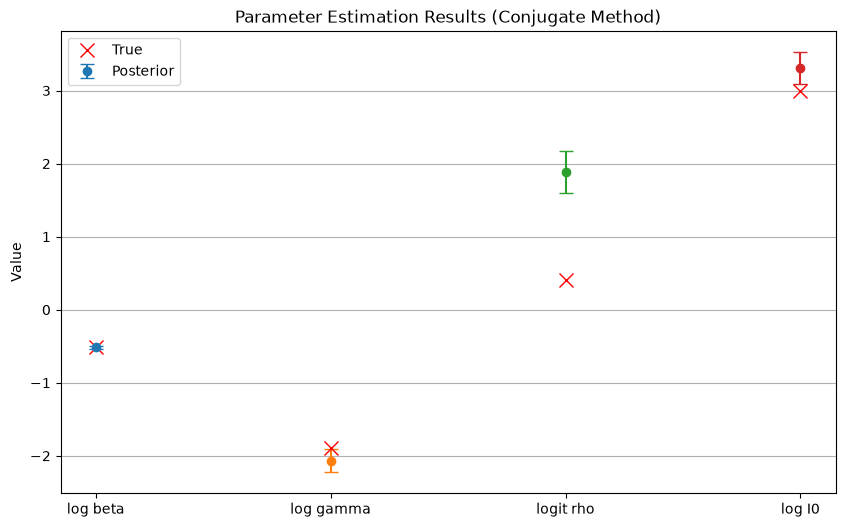

In [7]:
labels = ["log beta", "log gamma", "logit rho", "log I0"]
mu_n_np = mu_n.detach().cpu().numpy()
theta_true_np = theta_true.detach().cpu().numpy()
std_n_np = torch.sqrt(torch.diag(Sigma_n)).detach().cpu().numpy()

plt.figure(figsize=(10, 6))
for i in range(4):
    plt.errorbar(i, mu_n_np[i], yerr=std_n_np[i], fmt='o', capsize=5, label='Posterior' if i==0 else "")
    plt.plot(i, theta_true_np[i], 'rx', markersize=10, label='True' if i==0 else "")

plt.xticks(range(4), labels)
plt.ylabel("Value")
plt.title("Parameter Estimation Results (Conjugate Method)")
plt.legend()
plt.grid(True, axis='y')
plt.show()